# Fashion-MNIST classification with Support

This notebook follows the complete workflow from `simplest_possible_model.ipynb` while using the reusable classes in `src/support`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

try:
    from support import CNN, DatasetLoader, ImageUtils
except ModuleNotFoundError:
    from src.support import CNN, DatasetLoader, ImageUtils

I0000 00:00:1791223672.652576  140279 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791223672.653071  140279 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791223672.681283  140279 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791223673.218733  140279 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791223673.219019  140279 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Load the dataset

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [3]:
train = pd.DataFrame(x_train.reshape(len(x_train), -1))
train.insert(0, "label", y_train)
train.head()

,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

## Inspect an image

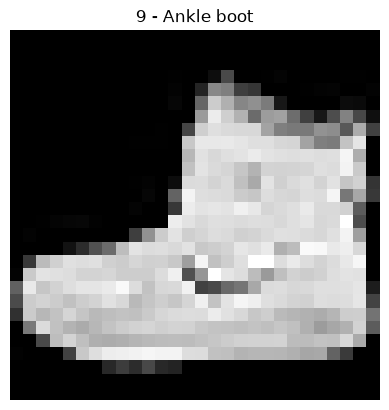

In [5]:
ImageUtils.show(
    x_train[0],
    title=f"{y_train[0]} - {labels[y_train[0]]}",
)

## Prepare the data

Pixel values are converted from the 0-255 range to the 0-1 range. The model accepts the 28 by 28 images and flattens them internally.

In [6]:
x_train = DatasetLoader.prepare_images(x_train)
x_test = DatasetLoader.prepare_images(x_test)
y_train_one_hot = CNN.one_hot(y_train, 10)

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())
print("One-hot label shape:", y_train_one_hot.shape)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
One-hot label shape: (60000, 10)


## Build and train the model

The support class initializes ten output neurons, applies softmax, calculates multiclass cross-entropy, and updates the weights and biases with gradient descent.

In [7]:
model = CNN(input_shape=(28, 28), num_classes=10, random_state=42)

history = model.fit(
    x_train,
    y_train_one_hot,
    learning_rate=0.1,
    max_epochs=100,
    tolerance=1e-4,
    batch_size=256,
    verbose=True,
)

epoch 1: loss=0.6058, accuracy=80.49%


epoch 100: loss=0.3825, accuracy=86.88%


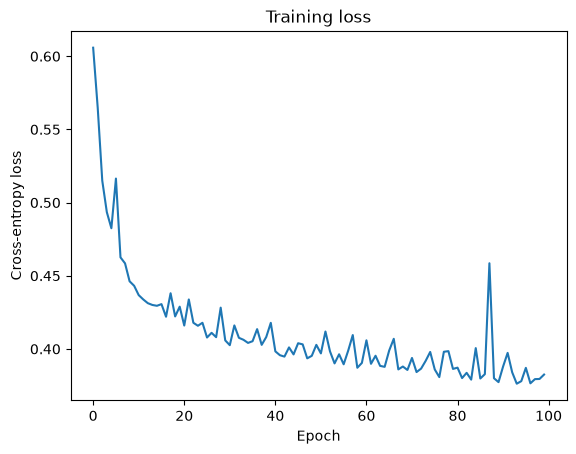

In [8]:
plt.plot(history["loss"])
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.show()

## Evaluate the model

In [9]:
train_result = model.evaluate(x_train, y_train)
test_result = model.evaluate(x_test, y_test)

print(f"Train loss: {train_result['loss']:.4f}")
print(f"Train accuracy: {train_result['accuracy']:.2%}")
print(f"Test loss: {test_result['loss']:.4f}")
print(f"Test accuracy: {test_result['accuracy']:.2%}")

Train loss: 0.3825
Train accuracy: 86.88%
Test loss: 0.4425
Test accuracy: 84.35%


## View predictions

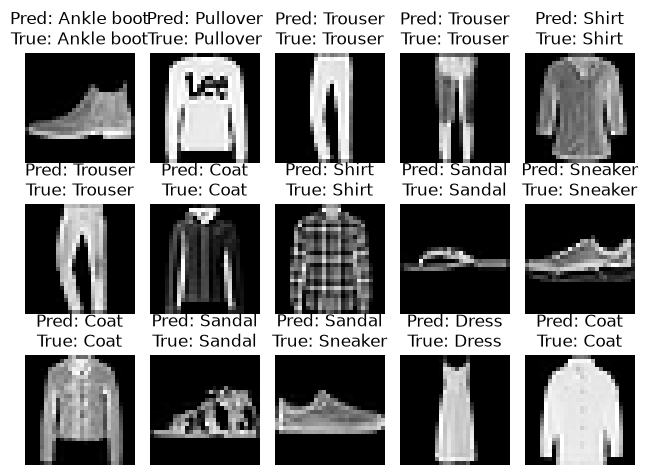

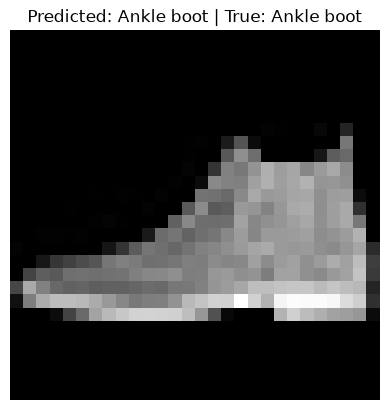

In [10]:
predictions = model.predict(x_test[:15])
titles = []

for prediction, actual in zip(predictions, y_test[:15]):
    titles.append(f"Pred: {labels[prediction]}\nTrue: {labels[actual]}")

prediction_image = ImageUtils.save_grid(
    x_test[:15],
    "outputs/fashion_mnist_predictions.png",
    columns=5,
    titles=titles,
)

from IPython.display import Image, display

display(Image(filename=str(prediction_image)))

ImageUtils.show(
    x_test[0],
    title=f"Predicted: {labels[predictions[0]]} | True: {labels[y_test[0]]}",
)

## Save and load the model

In [11]:
model_path = model.save("models/fashion_mnist.npz")
loaded_model = CNN.load(model_path)
loaded_predictions = loaded_model.predict(x_test[:15])

print("Model saved to:", model_path)
print("Loaded model predictions match:", np.array_equal(predictions, loaded_predictions))

Model saved to: models/fashion_mnist.npz
Loaded model predictions match: True
